# 01 — Análise Exploratória e Baseline

**Tech Challenge — Fase 1 · Etapa 1 (Ciclo de Vida e Fundamentos)**

## Situação de negócio
Uma operadora de telecomunicações perde clientes em ritmo acelerado. A diretoria
precisa identificar, **antes do cancelamento**, quais clientes têm alta propensão a
evadir, para direcionar a campanha de retenção a quem realmente importa.

## Objetivo deste notebook
1. Entender o volume, a qualidade e a distribuição dos dados.
2. Definir a métrica técnica e a métrica de negócio.
3. Treinar e documentar um **baseline** com Regressão Logística.

> Este notebook é de **experimentação**. Todo código que vai para produção mora em
> `src/churn/` e é importado aqui — nada é reescrito em duplicidade.

In [1]:
import sys
from pathlib import Path

# permite importar o pacote `churn` de src/ sem instalação
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from churn.config import (
    CATEGORICAL_FEATURES, FIGURES_DIR, NUMERIC_FEATURES,
    RANDOM_SEED, TARGET_COL, ensure_dirs, set_seeds,
)

set_seeds(RANDOM_SEED)
ensure_dirs()

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print(f"Seed fixada em {RANDOM_SEED}")


Seed fixada em 42


## 1. Carga dos dados brutos

In [2]:
from churn.data import load_raw_data

df_raw = load_raw_data()
print(f"Registros: {df_raw.shape[0]:,} | Colunas: {df_raw.shape[1]}")
df_raw.head()

Registros: 7,043 | Colunas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Qualidade dos dados

Três problemas conhecidos deste dataset precisam ser checados:
- `TotalCharges` vem como texto por conter espaços em branco;
- `customerID` é identificador puro (não carrega sinal preditivo e vaza cardinalidade);
- possíveis duplicatas.

In [4]:
qualidade = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "nulos": df_raw.isna().sum(),
    "% nulos": (df_raw.isna().mean() * 100).round(2),
    "valores_unicos": df_raw.nunique(),
})
qualidade

,dtype,nulos,% nulos,valores_unicos
customerID,str,0,0.0,7043
gender,str,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,str,0,0.0,2
Dependents,str,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,str,0,0.0,2
MultipleLines,str,0,0.0,3
InternetService,str,0,0.0,3
OnlineSecurity,str,0,0.0,3


In [5]:
# Onde estão os "nulos disfarçados" de TotalCharges?
mascara_vazia = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").isna()
print(f"Linhas com TotalCharges não numérico: {mascara_vazia.sum()}")
df_raw.loc[mascara_vazia, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Linhas com TotalCharges não numérico: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Diagnóstico:** as 11 linhas problemáticas são exatamente os clientes com
`tenure == 0`, ou seja, entraram na base e ainda não receberam a primeira fatura.
A imputação correta pela regra de negócio é **0.0**, não a mediana. Essa decisão está
implementada em `churn.data.clean_data()` e coberta por teste automatizado.

In [6]:
from churn.data import clean_data

df = clean_data(df_raw)
print(f"Antes: {df_raw.shape} -> Depois: {df.shape}")
print(f"Duplicatas removidas: {df_raw.shape[0] - df.shape[0]}")
print(f"Nulos restantes: {int(df.isna().sum().sum())}")
df.head(3)

Antes: (7043, 21) -> Depois: (7043, 20)
Duplicatas removidas: 0
Nulos restantes: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 3. Distribuição do alvo

Churn
No     5174
Yes    1869
Name: count, dtype: int64 

Churn
No     73.46 %
Yes    26.54 %
Name: proportion, dtype: str


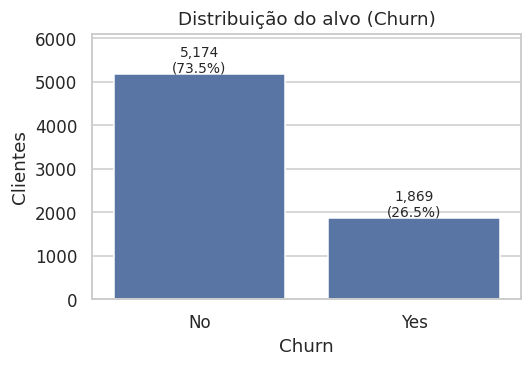

In [7]:
contagem = df[TARGET_COL].value_counts()
proporcao = df[TARGET_COL].value_counts(normalize=True)
print(contagem, "\n")
print((proporcao * 100).round(2).astype(str) + " %")

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=contagem.index, y=contagem.values, ax=ax)
for i, v in enumerate(contagem.values):
    ax.text(i, v + 40, f"{v:,}\n({proporcao.iloc[i]:.1%})", ha="center", fontsize=9)
ax.set_title("Distribuição do alvo (Churn)")
ax.set_ylabel("Clientes")
ax.set_ylim(0, contagem.max() * 1.18)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_distribuicao_alvo.png", bbox_inches="tight")
plt.show()

**Base desbalanceada: ~26,5% de churn.** Consequência prática: um classificador
que sempre responde "não vai cancelar" acerta 73,5% dos casos. Por isso **acurácia é
descartada** como métrica de decisão.

## 4. Variáveis numéricas

In [8]:
df[NUMERIC_FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.73,2266.79,0.00,398.55,1394.55,3786.60,8684.80
SeniorCitizen,7043.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00


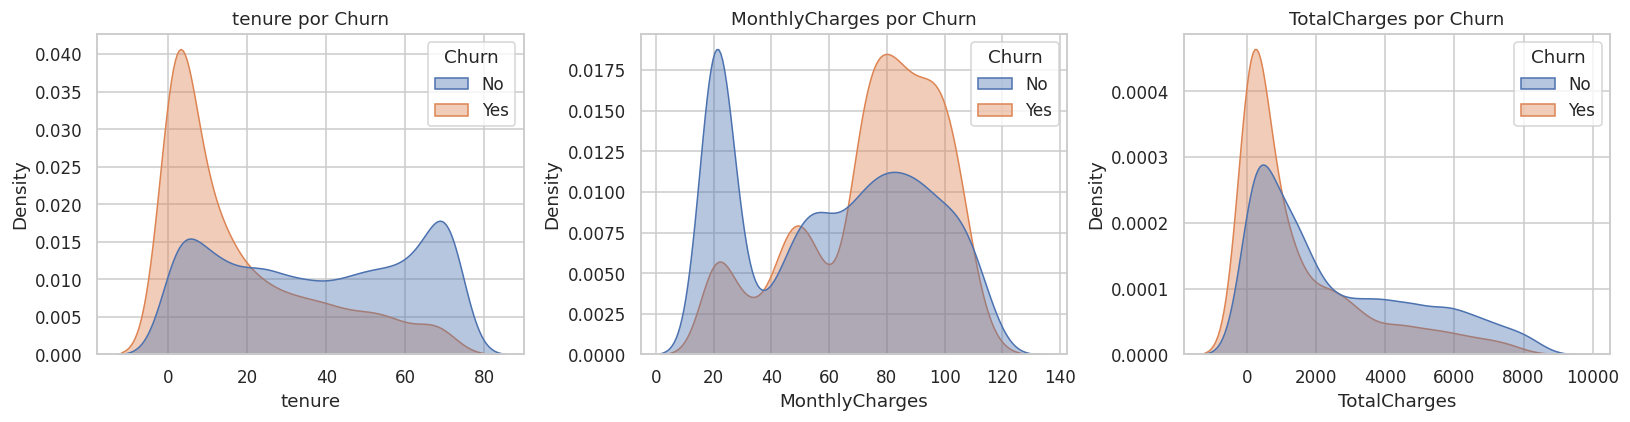

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue=TARGET_COL, fill=True, alpha=0.4,
                common_norm=False, ax=ax)
    ax.set_title(f"{col} por Churn")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_numericas_por_churn.png", bbox_inches="tight")
plt.show()

In [10]:
resumo = df.groupby(TARGET_COL)[["tenure", "MonthlyCharges", "TotalCharges"]].agg(["mean", "median"])
resumo.round(2)

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

**Leitura:** quem cancela tem **tenure** muito menor (mediana ~10 meses contra ~38)
e **MonthlyCharges** mais alta. `TotalCharges` é praticamente `tenure × MonthlyCharges`,
o que antecipa multicolinearidade — relevante para a Regressão Logística, irrelevante
para árvores.

## 5. Variáveis categóricas: taxa de churn por categoria

In [11]:
alvo_num = (df[TARGET_COL] == "Yes").astype(int)

taxas = []
for col in CATEGORICAL_FEATURES:
    agrupado = df.assign(_y=alvo_num).groupby(col)["_y"].agg(["mean", "size"])
    agrupado = agrupado.rename(columns={"mean": "taxa_churn", "size": "clientes"})
    agrupado["variavel"] = col
    taxas.append(agrupado.reset_index().rename(columns={col: "categoria"}))

tabela_taxas = pd.concat(taxas)[["variavel", "categoria", "clientes", "taxa_churn"]]
tabela_taxas["taxa_churn"] = tabela_taxas["taxa_churn"].round(4)
tabela_taxas.sort_values("taxa_churn", ascending=False).head(12)

,variavel,categoria,clientes,taxa_churn
2,PaymentMethod,Electronic check,2365,0.4529
0,Contract,Month-to-month,3875,0.4271
1,InternetService,Fiber optic,3096,0.4189
0,OnlineSecurity,No,3498,0.4177
0,TechSupport,No,3473,0.4164
0,OnlineBackup,No,3088,0.3993
0,DeviceProtection,No,3095,0.3913
0,StreamingMovies,No,2785,0.3368
1,PaperlessBilling,Yes,4171,0.3357
0,StreamingTV,No,2810,0.3352


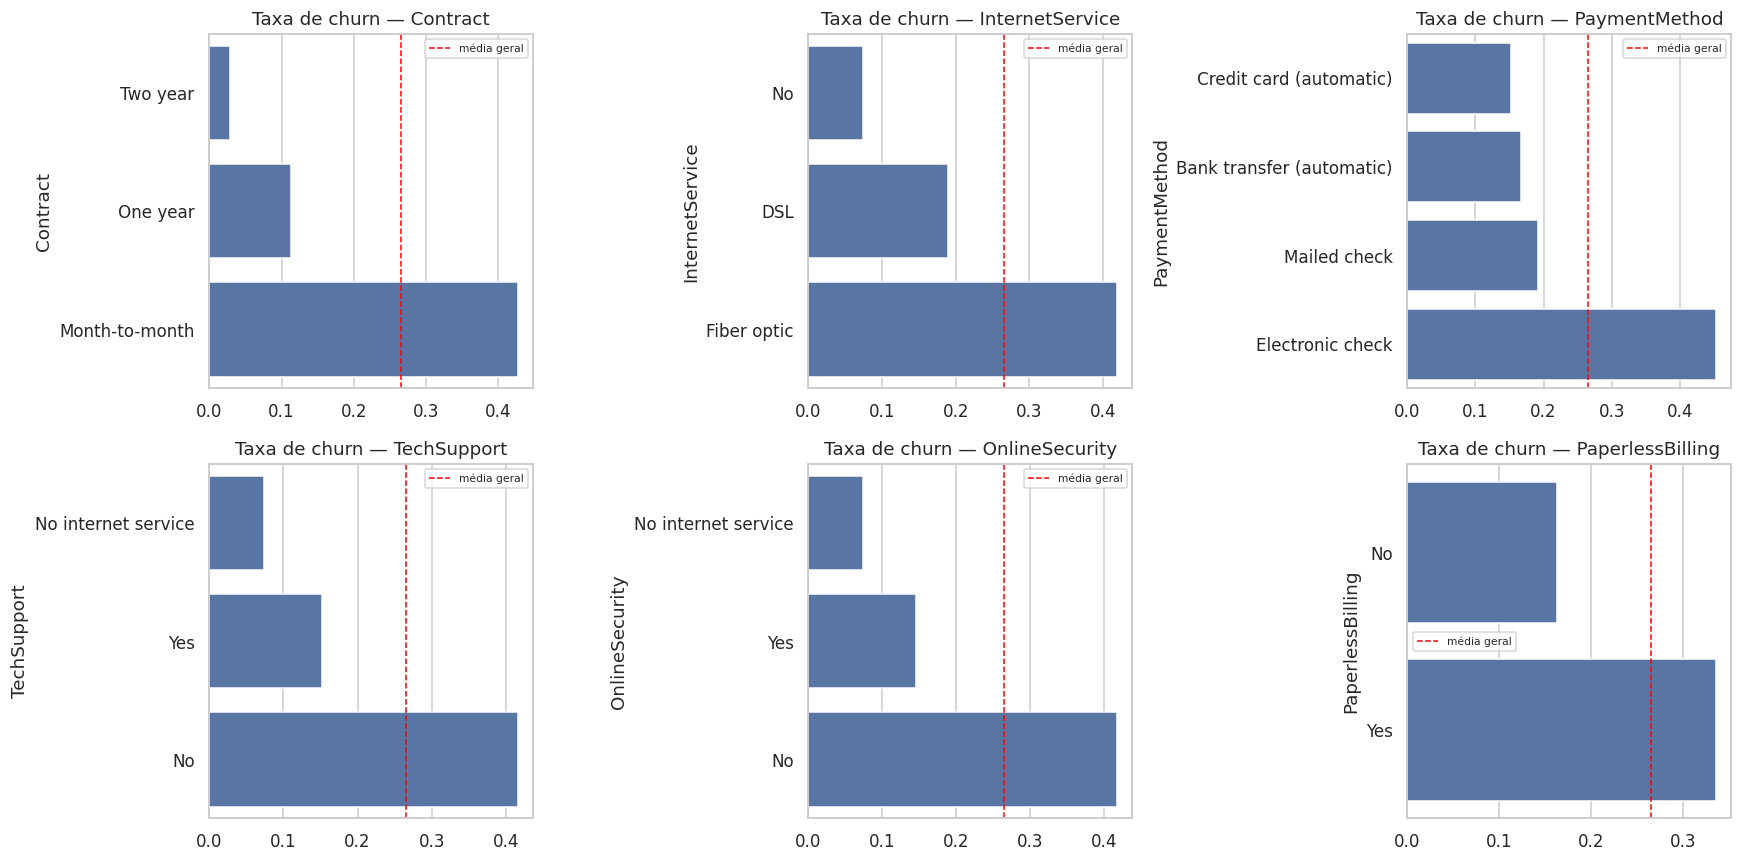

In [12]:
destaques = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
             "OnlineSecurity", "PaperlessBilling"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), destaques):
    dados = (df.assign(_y=alvo_num).groupby(col)["_y"].mean().sort_values())
    sns.barplot(x=dados.values, y=dados.index, ax=ax)
    ax.axvline(alvo_num.mean(), color="red", ls="--", lw=1, label="média geral")
    ax.set_title(f"Taxa de churn — {col}")
    ax.set_xlabel("")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_categoricas_taxa_churn.png", bbox_inches="tight")
plt.show()

### Principais achados da EDA

| Achado | Evidência | Implicação |
|---|---|---|
| Contrato mensal é o maior fator de risco | ~42,7% de churn contra ~2,8% no contrato de 2 anos | Feature mais forte do modelo; alavanca direta de retenção |
| Fibra óptica evade mais que DSL | ~41,9% contra ~19,0% | Investigar qualidade percebida do serviço |
| Cheque eletrônico concentra risco | ~45,3% de churn | Migrar cliente para débito automático é ação de baixo custo |
| Ausência de suporte técnico / segurança online eleva o risco | ~41,6% sem TechSupport | Oferta de serviços agregados como retenção |
| Os primeiros meses são críticos | mediana de tenure de 10 meses entre quem evade | Onboarding é o momento de intervir |
| `gender` é irrelevante | taxa praticamente idêntica entre os grupos | Candidata a descarte; mantida para checagem de viés |

## 6. Definição das métricas

### Métrica técnica principal — F1 da classe positiva
A base tem 26,5% de churn. Precisamos equilibrar dois erros de custos diferentes:
- **Falso negativo:** cliente evade sem ser abordado → perda de receita.
- **Falso positivo:** desconto dado a quem ficaria de qualquer forma → custo de campanha.

O F1 da classe positiva é a média harmônica de precisão e recall, penaliza os dois
erros e não é inflado pela classe majoritária. Como métrica secundária usamos
**ROC-AUC**, que mede a qualidade do ranqueamento independentemente do limiar.

### Métrica de negócio — lucro líquido da campanha de retenção

| Situação | Valor unitário |
|---|---|
| Verdadeiro positivo (cliente em risco retido) | **+ R$ 850** |
| Falso positivo (incentivo desperdiçado) | **− R$ 150** |
| Falso negativo (cliente perdido) | **− R$ 1.000** |
| Verdadeiro negativo | R$ 0 |

Implementada em `churn.evaluate.business_value()`. Como o falso negativo custa
~6,7× mais que o falso positivo, o negócio tolera perder precisão em troca de recall
— o que justifica calibrar o limiar de decisão em vez de fixá-lo em 0,5.

## 7. Baseline — Regressão Logística

In [13]:
from churn.data import get_train_test_split
from churn.evaluate import compute_metrics, confusion_dict, find_best_threshold
from churn.models import build_logistic_regression

X_train, X_test, y_train, y_test = get_train_test_split(df)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Churn no treino: {y_train.mean():.2%} | no teste: {y_test.mean():.2%}")

Treino: (5634, 19) | Teste: (1409, 19)
Churn no treino: 26.54% | no teste: 26.54%


In [14]:
baseline = build_logistic_regression()
baseline.fit(X_train, y_train)

proba_baseline = baseline.predict_proba(X_test)[:, 1]
metricas_baseline = compute_metrics(y_test, proba_baseline, threshold=0.5)

pd.Series(metricas_baseline.to_dict()).round(4).to_frame("baseline_logreg")

,baseline_logreg
threshold,0.5000
f1,0.6136
precision,0.5043
recall,0.7834
roc_auc,0.8417
pr_auc,0.6327
accuracy,0.7381
business_value,124850.0000


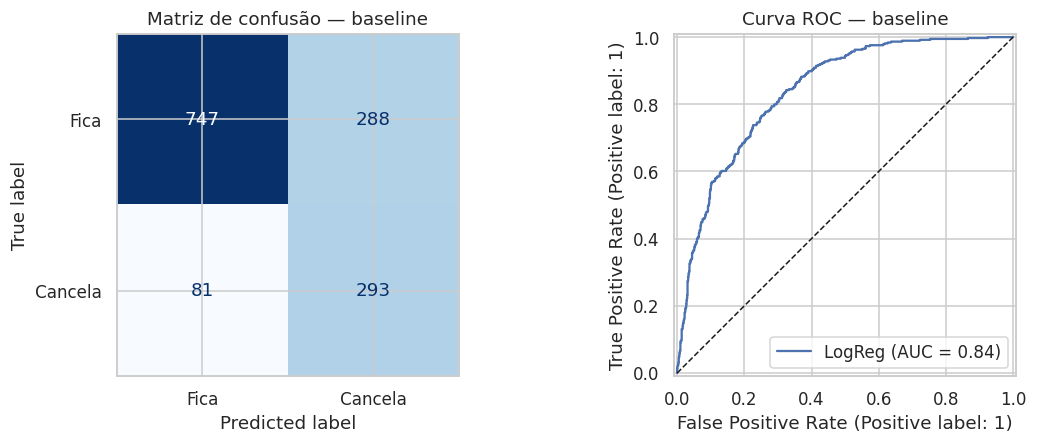

{'true_negative': 747, 'false_positive': 288, 'false_negative': 81, 'true_positive': 293}


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay.from_predictions(
    y_test, (proba_baseline >= 0.5).astype(int),
    display_labels=["Fica", "Cancela"], cmap="Blues", ax=axes[0], colorbar=False,
)
axes[0].set_title("Matriz de confusão — baseline")
RocCurveDisplay.from_predictions(y_test, proba_baseline, ax=axes[1], name="LogReg")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("Curva ROC — baseline")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_baseline_avaliacao.png", bbox_inches="tight")
plt.show()

print(confusion_dict(y_test, proba_baseline, 0.5))

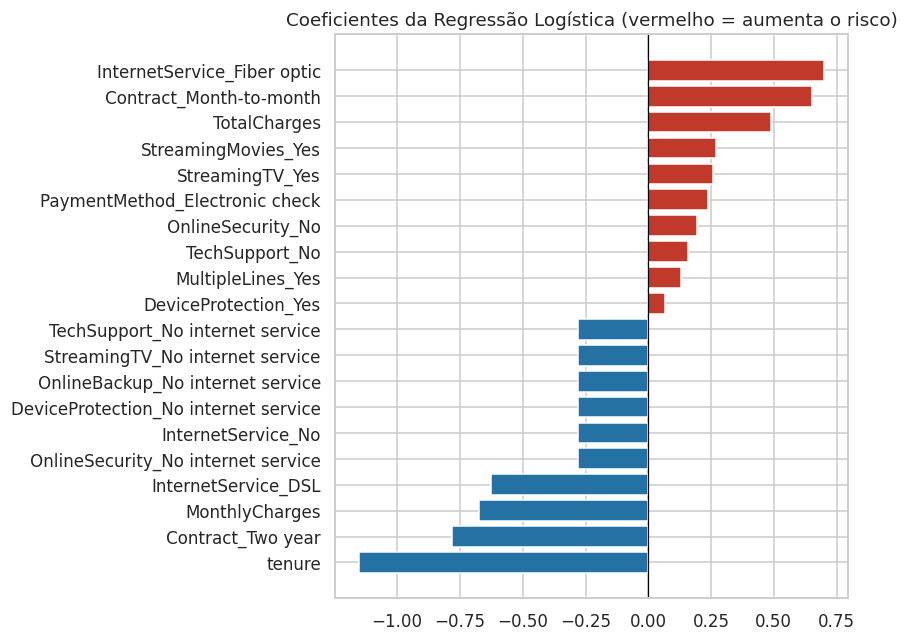

In [16]:
# Coeficientes: o que a Regressão Logística aprendeu
nomes = baseline.named_steps["preprocessor"].get_feature_names_out()
coeficientes = pd.Series(baseline.named_steps["classifier"].coef_[0], index=nomes)
top = pd.concat([coeficientes.nlargest(10), coeficientes.nsmallest(10)]).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
cores = ["#c0392b" if v > 0 else "#2471a3" for v in top.values]
ax.barh(top.index, top.values, color=cores)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Coeficientes da Regressão Logística (vermelho = aumenta o risco)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_coeficientes_baseline.png", bbox_inches="tight")
plt.show()

In [17]:
# Efeito de calibrar o limiar de decisão
limiar_f1, valor_f1 = find_best_threshold(y_test, proba_baseline, metric="f1")
limiar_negocio, valor_negocio = find_best_threshold(y_test, proba_baseline, metric="business_value")

print(f"Limiar que maximiza F1:      {limiar_f1:.2f}  ->  F1 = {valor_f1:.4f}")
print(f"Limiar que maximiza o lucro: {limiar_negocio:.2f}  ->  R$ {valor_negocio:,.2f}")
print(f"Lucro no limiar padrão 0.50: R$ {metricas_baseline.business_value:,.2f}")

Limiar que maximiza F1:      0.54  ->  F1 = 0.6224
Limiar que maximiza o lucro: 0.18  ->  R$ 211,200.00
Lucro no limiar padrão 0.50: R$ 124,850.00


## 8. Conclusão da Etapa 1

- Dataset com 7.043 clientes, 19 features e alvo binário desbalanceado (26,5% de churn).
- Única sujeira relevante: 11 valores em branco em `TotalCharges`, tratados por regra de
  negócio e cobertos por teste.
- Métrica técnica: **F1 da classe positiva**; secundária: ROC-AUC; de negócio: lucro
  líquido da campanha.
- **Baseline (Regressão Logística) entrega F1 ≈ 0,61 e ROC-AUC ≈ 0,84.** É a régua que os
  modelos da Etapa 2 precisam superar para justificar sua complexidade.

Próximo passo: `02_modelagem_e_comparacao.ipynb`.